In [2]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/variant_class.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

In [3]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [ ]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

selected_categories = ['plof', 'missense', 'conservation', 'splicing'] # Gene-Body
# selected_categories = ['missense'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'] # non coding
# selected_categories = ['encode_regions'] # encode regions
# selected_categories = ['encode_custom'] # encode regions custom
# selected_categories = ['conservation', 'regulatory_nondir', 'genetic_diversity'] # 5UTR

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

In [6]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == 1
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr4:113211828:C:A""","""ENSG00000145362""","""loftee_hc""",0.0
"""chr2:157747637:T:C""","""ENSG00000115170""","""loftee_hc""",0.0
"""chr1:214508142:C:G""","""ENSG00000152104""","""loftee_hc""",0.0
"""chr6:128404170:G:A""","""ENSG00000152894""","""loftee_hc""",0.0
"""chr7:860160:C:A""","""ENSG00000164828""","""loftee_hc""",0.0
…,…,…,…
"""chr7:90747506:T:A""","""ENSG00000058091""","""gpn_score""",-5.51
"""chr9:120981935:G:A""","""ENSG00000106804""","""gpn_score""",-3.92
"""chr17:64541107:C:T""","""ENSG00000108854""","""gpn_score""",-0.02


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (7863, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000213398""","""mean_sphered_cell_volume_int""","""am_pathogenicity""",3823,0.070215,"""#feb72d""","""AlphaMissense""",1,0.038548,0.034706,0.034706,1.0,0.070215,2.023115
"""ENSG00000167658""","""mean_corpuscular_volume_int""","""revel_score""",5503,0.026504,"""#feb72d""","""REVEL""",1,0.007736,0.052769,0.052769,1.0,0.026504,0.502255
"""ENSG00000108021""","""forced_expiratory_volume_in_1s…","""am_pathogenicity""",16988,-0.008197,"""#feb72d""","""AlphaMissense""",1,0.049613,-0.009398,0.009398,-1.0,0.008197,0.872246
"""ENSG00000162711""","""creactive_protein_int""","""esmscoremissense""",10008,0.039147,"""#feb72d""","""ESM1v""",-1,0.000012,-0.043868,0.043868,-1.0,0.039147,0.892397
"""ENSG00000236320""","""platelet_distribution_width_in…","""gpn_score""",4785,0.028949,"""#942c80""","""GPN-MSA""",-1,0.03134,-0.029907,0.029907,-1.0,0.028949,0.967997
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""am_pathogenicity""",57095,0.006721,"""#feb72d""","""AlphaMissense""",1,2.3369e-43,0.035341,0.035341,1.0,0.006721,0.190174
"""ENSG00000198604""","""mean_reticulocyte_volume_int""","""loftee_hc""",23548,0.032613,"""#E31A1C""","""LOFTEE HC""",1,0.010085,0.032613,0.032613,1.0,0.032613,1.0
"""ENSG00000106105""","""alkaline_phosphatase_int""","""gpn_score""",12016,-0.015802,"""#942c80""","""GPN-MSA""",-1,0.010566,0.021689,0.021689,1.0,0.015802,0.72854


In [9]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000213398""","""mean_sphered_cell_volume_int""","""am_pathogenicity""",3823,0.070215,"""#feb72d""","""AlphaMissense""",1,0.038548,0.034706,0.034706,1.0,0.070215,2.023115,12
"""ENSG00000167658""","""mean_corpuscular_volume_int""","""revel_score""",5503,0.026504,"""#feb72d""","""REVEL""",1,0.007736,0.052769,0.052769,1.0,0.026504,0.502255,12
"""ENSG00000236320""","""platelet_distribution_width_in…","""gpn_score""",4785,0.028949,"""#942c80""","""GPN-MSA""",-1,0.03134,-0.029907,0.029907,-1.0,0.028949,0.967997,12
"""ENSG00000118762""","""cystatin_c_int""","""delta_score""",15135,0.003119,"""#28a745""","""SpliceAI""",1,6.5048e-17,0.038499,0.038499,1.0,0.003119,0.081003,12
"""ENSG00000115464""","""igf1_int""","""revel_score""",75599,-0.00025,"""#feb72d""","""REVEL""",1,0.002321,-0.011244,0.011244,-1.0,0.00025,0.022274,12
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000071537""","""red_blood_cell_erythrocyte_dis…","""absplice2_max""",14183,-0.001611,"""#28a745""","""AbSplice2 (max)""",1,0.023778,-0.02504,0.02504,-1.0,0.001611,0.064348,12
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""am_pathogenicity""",57095,0.006721,"""#feb72d""","""AlphaMissense""",1,2.3369e-43,0.035341,0.035341,1.0,0.006721,0.190174,12
"""ENSG00000198604""","""mean_reticulocyte_volume_int""","""loftee_hc""",23548,0.032613,"""#E31A1C""","""LOFTEE HC""",1,0.010085,0.032613,0.032613,1.0,0.032613,1.0,12


In [11]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


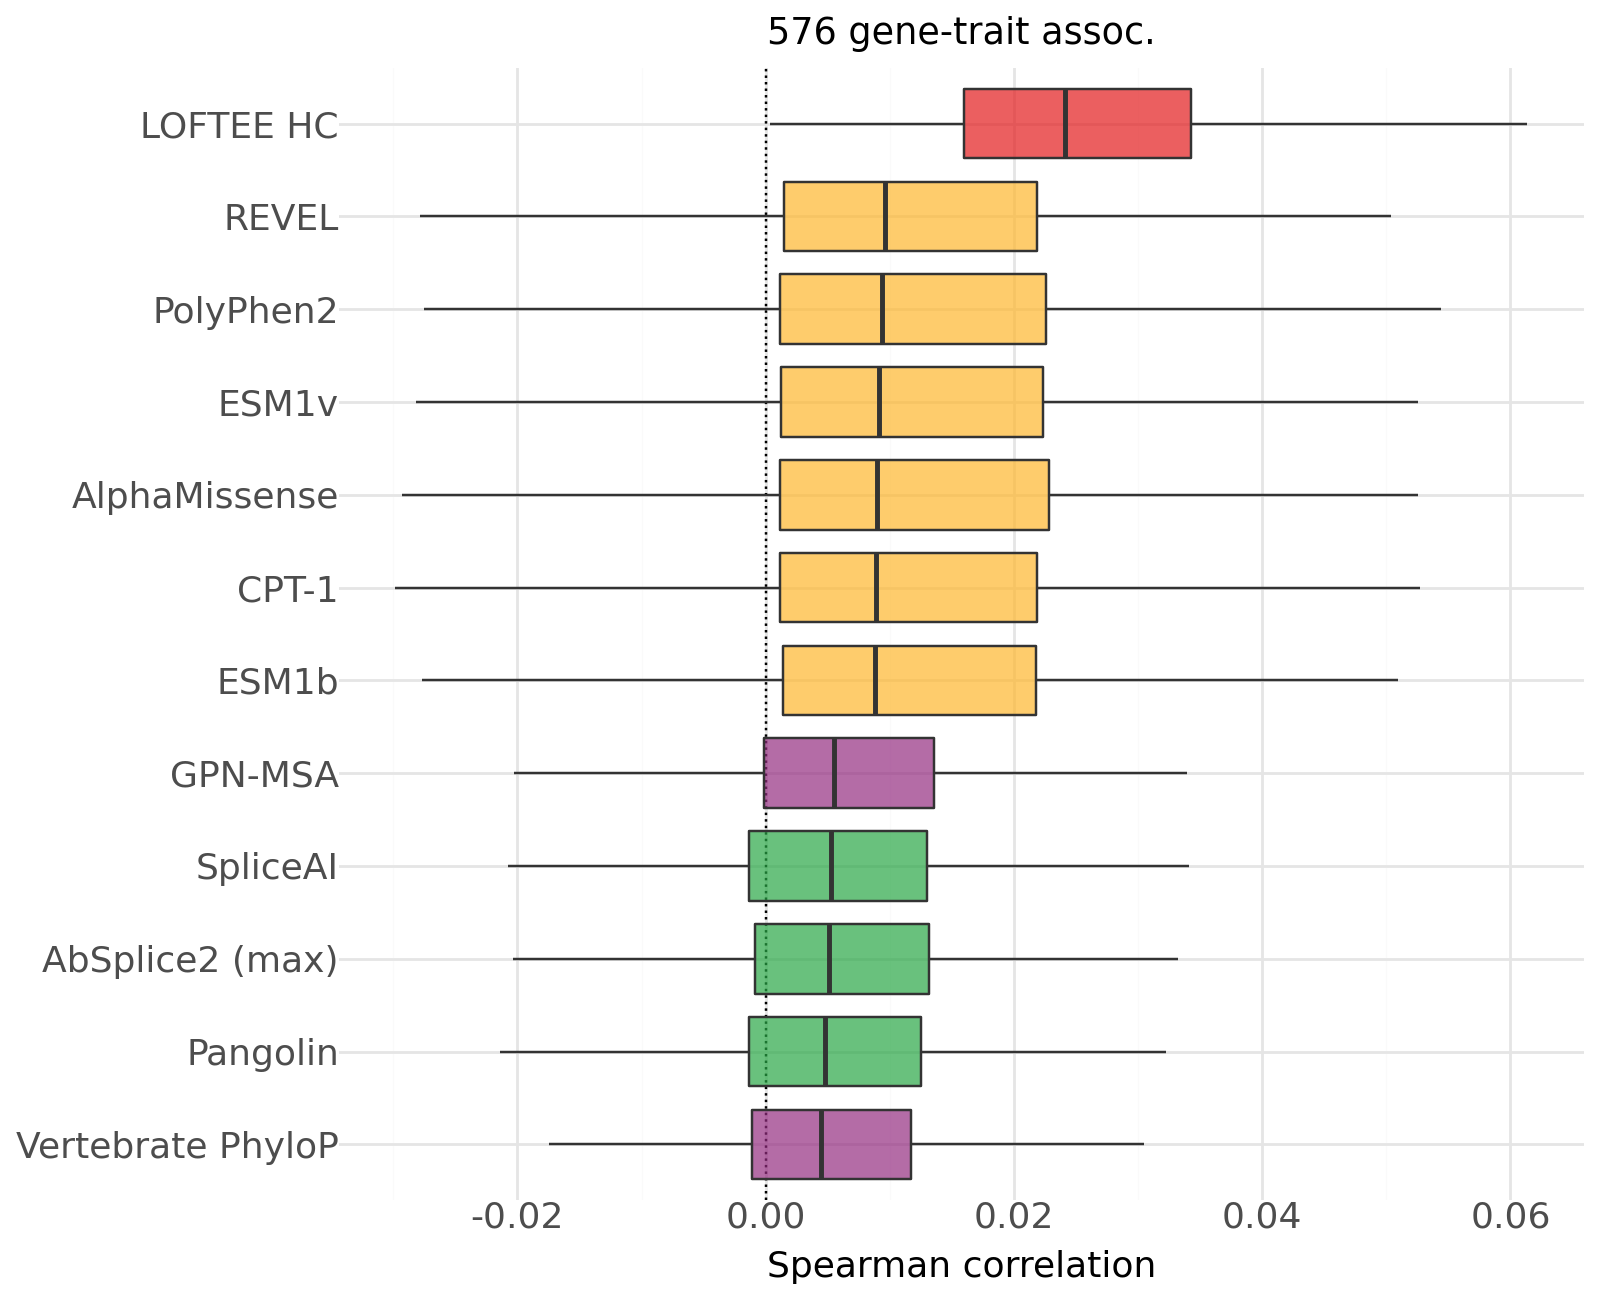

In [12]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [13]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_411136/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""verphylop""","""loftee_hc""",576,2613.0,3.3140e-90
"""loftee_hc""","""pangolin_score""",576,3168.0,5.4200e-89
"""delta_score""","""loftee_hc""",576,4336.0,1.8232e-86
"""absplice2_max""","""loftee_hc""",576,4531.0,4.7762e-86
"""gpn_score""","""loftee_hc""",576,4641.0,8.2142e-86
…,…,…,…,…
"""gpn_score""","""verphylop""",576,71139.0,0.002786
"""am_pathogenicity""","""polyphen""",576,71687.0,0.004328
"""esmscoremissense""","""polyphen""",576,74133.0,0.025021


# Stratify by LOEUF score

In [ ]:
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
        # pl.col('mane_select')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

gnom

region,loeuf
str,f64
"""ENSG00000121410""",1.34
"""ENSG00000148584""",0.825
"""ENSG00000175899""",0.765
"""ENSG00000166535""",0.953
"""ENSG00000184389""",1.529
…,…
"""ENSG00000288914""",1.87
"""ENSG00000289027""",0.885
"""ENSG00000289258""",0.982


In [ ]:
set(correlation_df['region'].unique()) - set(gnom['region'].unique())

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 19'. Pick better value with 'binwidth'.


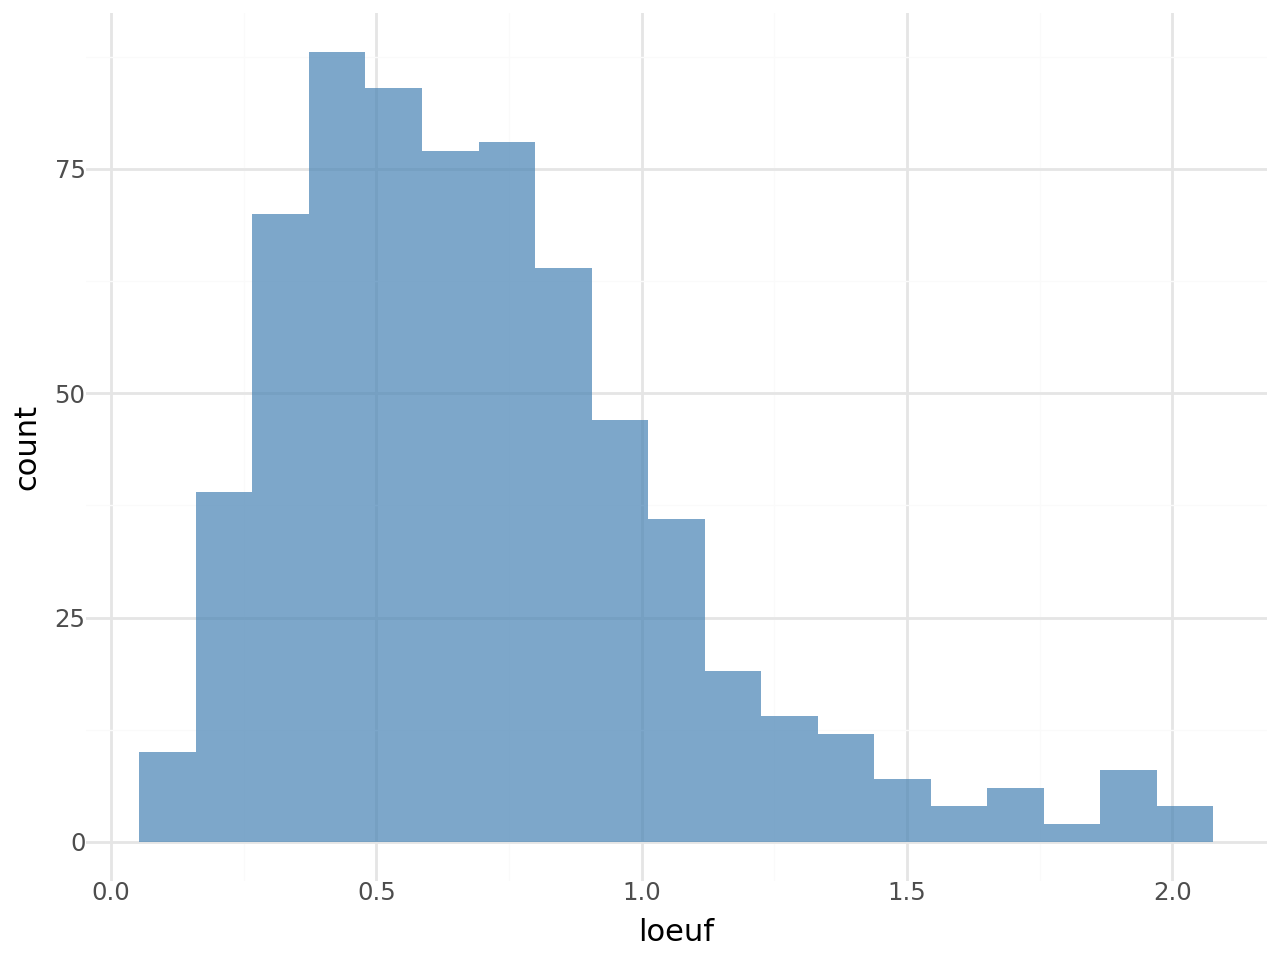

In [40]:
tmp = gnom.join(correlation_df.select(['region']).unique(), on='region', how='inner').with_columns(subset=pl.lit('ukbbgym_pheno'))

(
    ggplot(tmp, aes(x='loeuf'))
    + geom_histogram(position='identity', fill='steelblue', alpha=0.7)
    + theme_minimal()
)

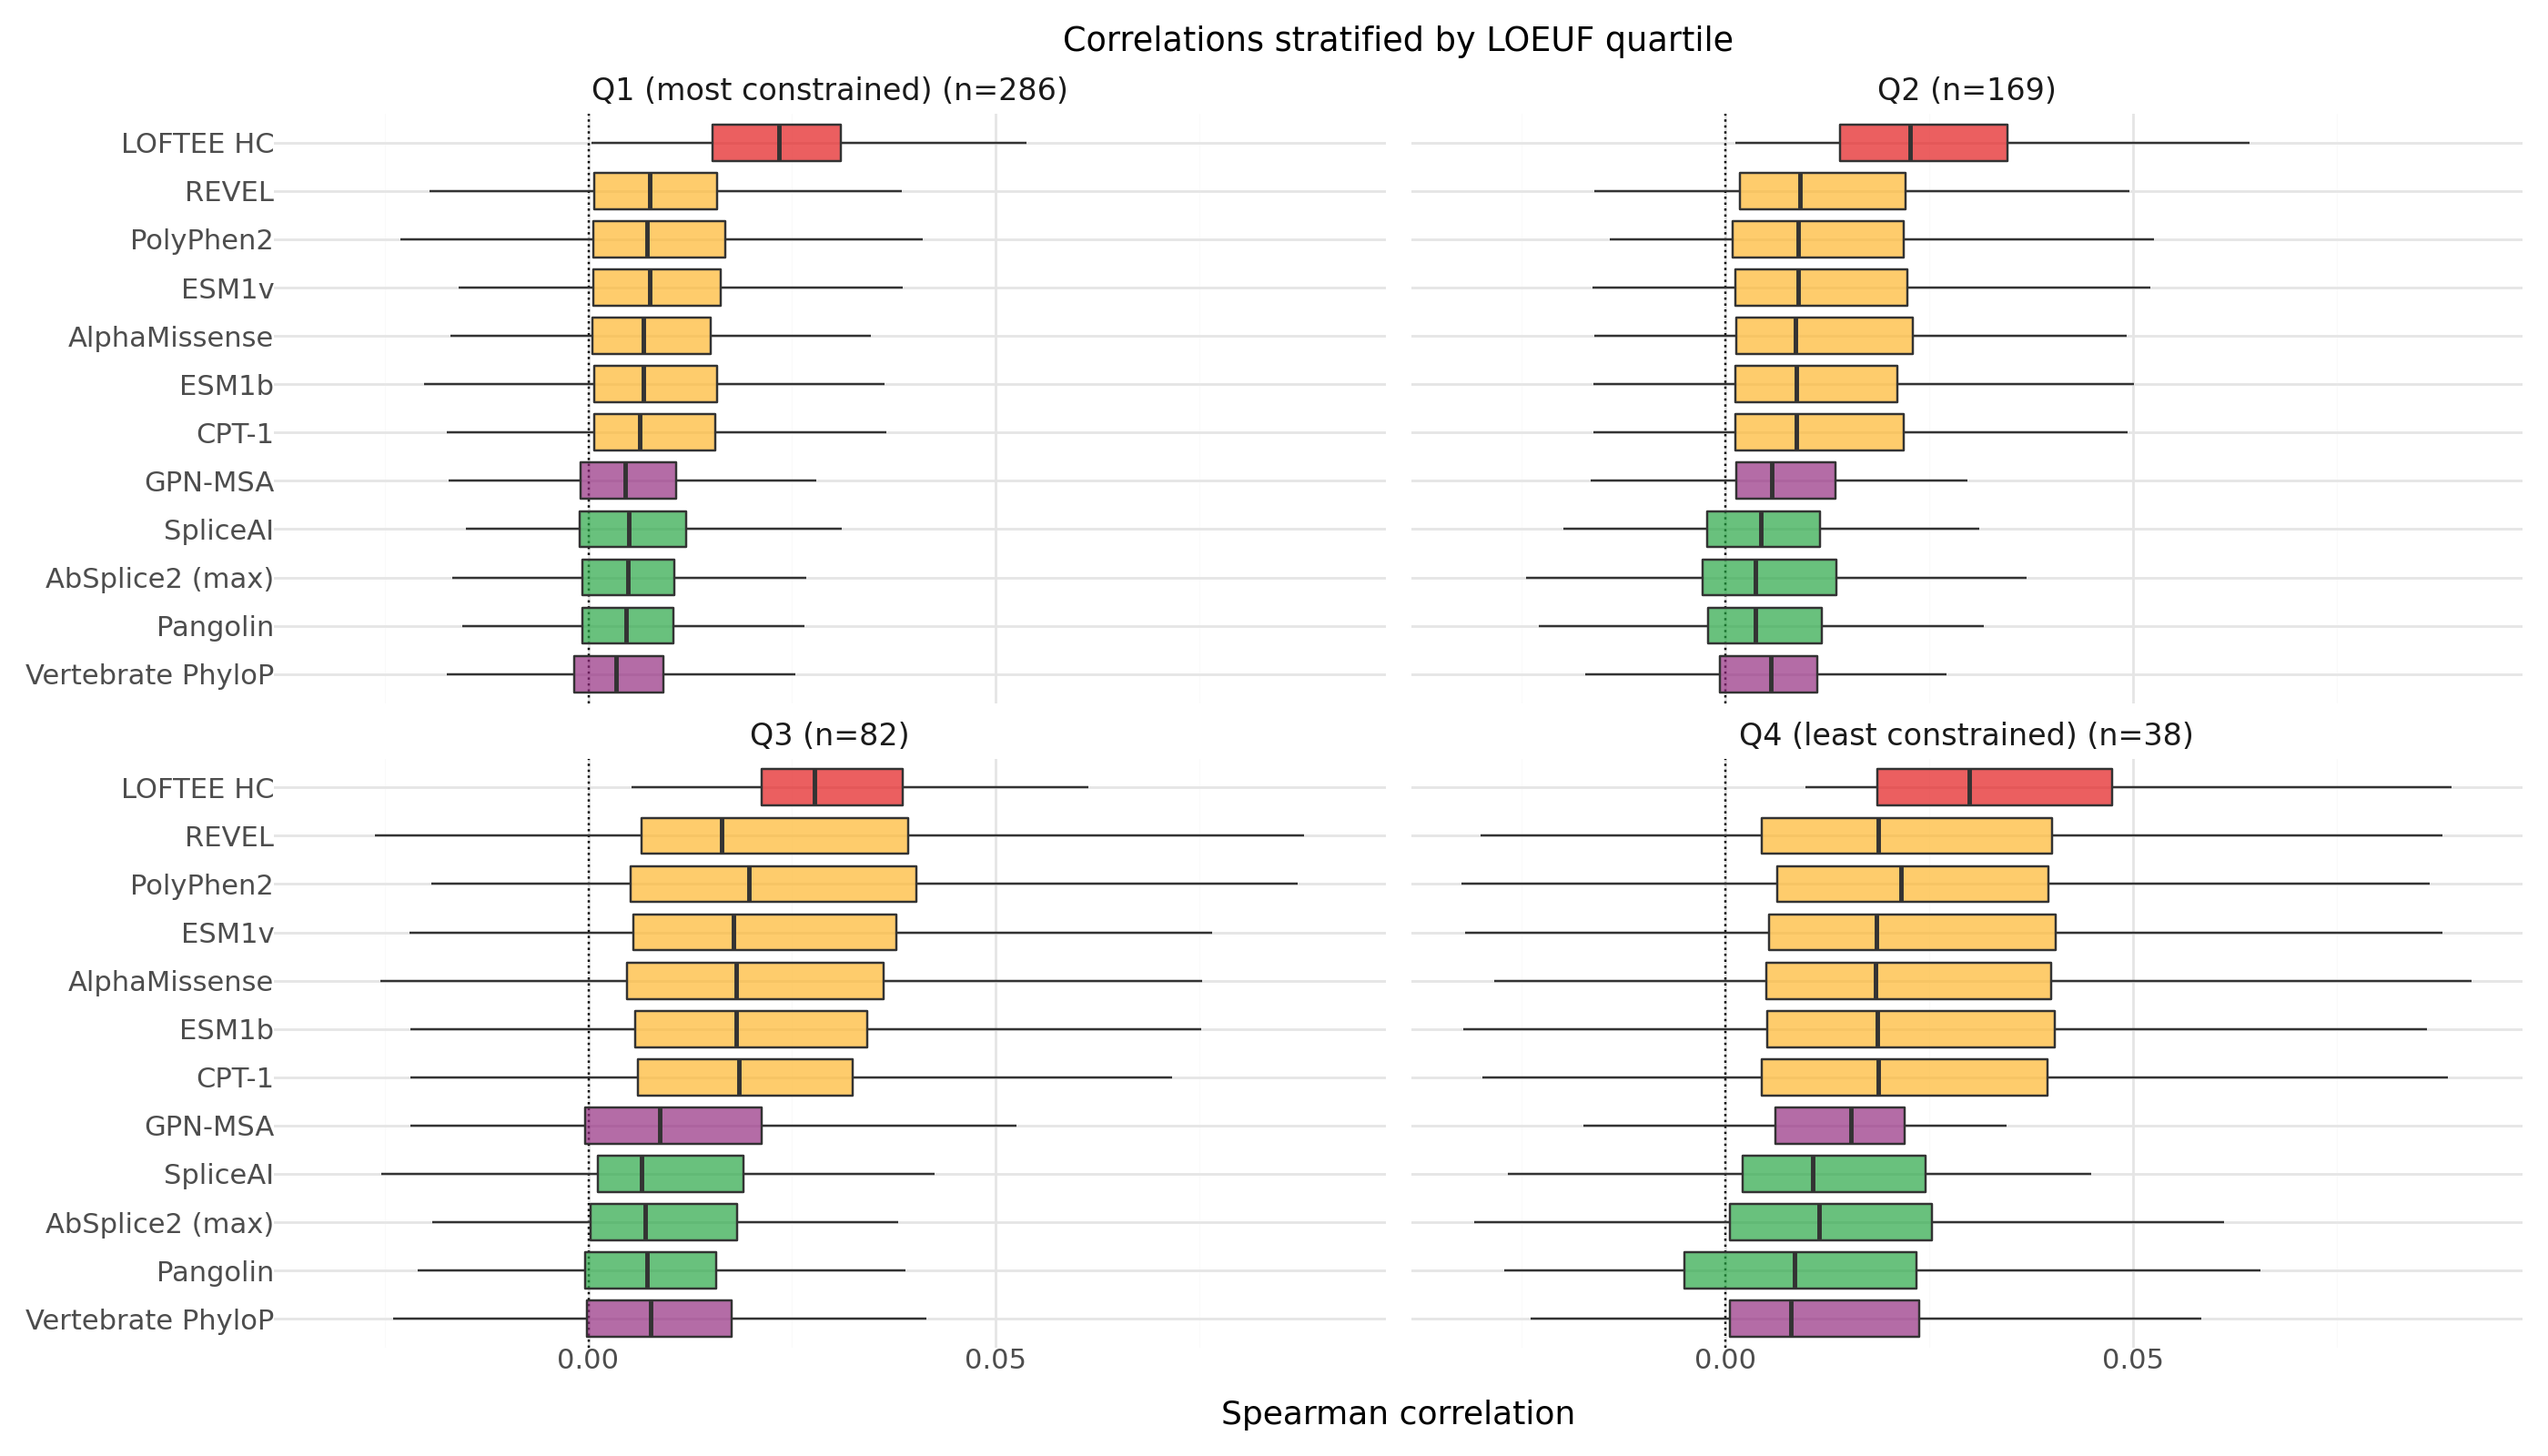

In [47]:
# Create 4 LOEUF bins from the full gnomAD constraint table
loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(4, labels=['Q1 (most constrained)', 'Q2', 'Q3', 'Q4 (least constrained)'])
)

# Join LOEUF bins to filt_corr_df
corr_loeuf = (
    filt_corr_df
    .join(loeuf_bins, on='region', how='inner')
    .drop_nans()
)

# Add n= counts to the bin labels
bin_counts = (
    corr_loeuf
    .select(['region', 'phenotype', 'loeuf_bin'])
    .unique(subset=['region', 'phenotype'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {
    row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()
}
corr_loeuf = corr_loeuf.with_columns(
    pl.col('loeuf_bin').cast(pl.Utf8).replace(bin_label_map).alias('loeuf_bin')
)

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Order annotations by overall median
corr_loeuf_pl = corr_loeuf.with_columns(
    median_corr_beta = pl.col(plotting_col).median().over("annotation")
)

ordered_labels = (
    corr_loeuf_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

corr_loeuf_pl = corr_loeuf_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

color_dict = dict(corr_loeuf_pl.select("annotation", "color").unique().iter_rows())

(
    ggplot(corr_loeuf_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + facet_wrap("~loeuf_bin", ncol=2)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Correlations stratified by LOEUF quartile"
    )
    + coord_flip()
    + theme(
        figure_size=(14, corr_loeuf_pl['annotation'].n_unique()/2 + 2),
        legend_position="none",
        axis_text=element_text(size=11),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)